# Exploratory Data Analysis (EDA)

## 1. Import Libraries and Locate Processed Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from IPython.display import display
except ImportError:
    def display(dataframe):
        print(dataframe.to_string())

PROJECT_ROOT = Path.cwd().resolve()

while (
    not (PROJECT_ROOT / "data" / "processed").exists()
    and PROJECT_ROOT != PROJECT_ROOT.parent
):
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "Could not find data/processed/. Open the notebook from inside "
        "the project folder."
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data folder: {DATA_DIR}")

Project root: D:\VS CODE\AI-Powered-Operating-Intelligence-Platform
Processed data folder: D:\VS CODE\AI-Powered-Operating-Intelligence-Platform\data\processed


## 2. Load All Cleaned Datasets

In [3]:
def load_dataset(filename):
    file_path = DATA_DIR / filename

    if not file_path.exists():
        raise FileNotFoundError(
            f"Processed dataset not found: {file_path}"
        )

    return pd.read_csv(
        file_path,
        keep_default_na=False,
    )


products = load_dataset("products_cleaned.csv")
stores = load_dataset("stores_cleaned.csv")
vendors = load_dataset("vendors_cleaned.csv")
employees = load_dataset("employees_cleaned.csv")
sales = load_dataset("sales_cleaned.csv")
inventory = load_dataset("inventory_cleaned.csv")
complaints = load_dataset("complaints_cleaned.csv")
finance = load_dataset("finance_cleaned.csv")
vendor_deliveries = load_dataset(
    "vendor_deliveries_cleaned.csv"
)

print("All cleaned datasets loaded successfully.")

All cleaned datasets loaded successfully.


## 3. Prepare Dates and Numeric Columns

In [4]:
sales["date"] = pd.to_datetime(
    sales["date"],
    format="%Y-%m-%d",
)

inventory["date"] = pd.to_datetime(
    inventory["date"],
    format="%Y-%m-%d",
)

inventory["expiry_date"] = pd.to_datetime(
    inventory["expiry_date"],
    format="%Y-%m-%d",
    errors="coerce",
)

complaints["date"] = pd.to_datetime(
    complaints["date"],
    format="%Y-%m-%d",
)

vendor_deliveries["order_date"] = pd.to_datetime(
    vendor_deliveries["order_date"],
    format="%Y-%m-%d",
)

vendor_deliveries["expected_delivery_date"] = pd.to_datetime(
    vendor_deliveries["expected_delivery_date"],
    format="%Y-%m-%d",
)

vendor_deliveries["actual_delivery_date"] = pd.to_datetime(
    vendor_deliveries["actual_delivery_date"],
    format="%Y-%m-%d",
)

sales_numeric_columns = [
    "quantity_sold",
    "unit_price",
    "discount_percent",
    "total_sales",
    "total_cost",
    "profit",
]

inventory_numeric_columns = [
    "current_stock",
    "reorder_level",
]

finance_numeric_columns = [
    "monthly_sales_target",
    "total_revenue",
    "total_cost",
    "gross_profit",
    "operating_expense",
    "operating_profit",
    "target_achievement_percent",
]

vendor_numeric_columns = [
    "ordered_quantity",
    "received_quantity",
    "unit_cost",
    "purchase_value",
    "delay_days",
    "quality_rating",
]

for column in sales_numeric_columns:
    sales[column] = pd.to_numeric(
        sales[column],
        errors="coerce",
    )

for column in inventory_numeric_columns:
    inventory[column] = pd.to_numeric(
        inventory[column],
        errors="coerce",
    )

for column in finance_numeric_columns:
    finance[column] = pd.to_numeric(
        finance[column],
        errors="coerce",
    )

for column in vendor_numeric_columns:
    vendor_deliveries[column] = pd.to_numeric(
        vendor_deliveries[column],
        errors="coerce",
    )

inventory["days_to_expiry"] = (
    inventory["expiry_date"] - inventory["date"]
).dt.days

sales["month"] = sales["date"].dt.to_period("M").astype(str)

print("Dates and numeric columns prepared successfully.")

Dates and numeric columns prepared successfully.


## 4. Dataset Overview

In [5]:
dataset_overview = pd.DataFrame(
    {
        "Dataset": [
            "Products",
            "Stores",
            "Vendors",
            "Employees",
            "Sales",
            "Inventory",
            "Complaints",
            "Finance",
            "Vendor Deliveries",
        ],
        "Rows": [
            len(products),
            len(stores),
            len(vendors),
            len(employees),
            len(sales),
            len(inventory),
            len(complaints),
            len(finance),
            len(vendor_deliveries),
        ],
        "Columns": [
            len(products.columns),
            len(stores.columns),
            len(vendors.columns),
            len(employees.columns),
            len(sales.columns),
            len(inventory.columns),
            len(complaints.columns),
            len(finance.columns),
            len(vendor_deliveries.columns),
        ],
    }
)

display(dataset_overview)

,Dataset,Rows,Columns
0,Products,25,12
1,Stores,10,10
2,Vendors,10,11
3,Employees,25,10
4,Sales,44435,17
5,Inventory,250,14
6,Complaints,1572,15
7,Finance,60,13
8,Vendor Deliveries,85,18


## 5. Sales KPI Summary and Monthly Trend

,KPI,Value
0,Total Sales,39064024.80
1,Total Profit,8663194.80
2,Total Transactions,44435.00
3,Total Quantity Sold,262646.00
4,Average Transaction Value,879.13
5,Average Discount Percent,3.51


,month,total_sales,total_profit,transaction_count
0,2026-01,6847294.1,1528705.1,7739
1,2026-02,6219178.5,1374379.5,6997
2,2026-03,6577859.8,1463605.8,7448
3,2026-04,6626111.0,1474290.0,7407
4,2026-05,6622437.8,1459923.8,7449
5,2026-06,6171143.6,1362290.6,7395


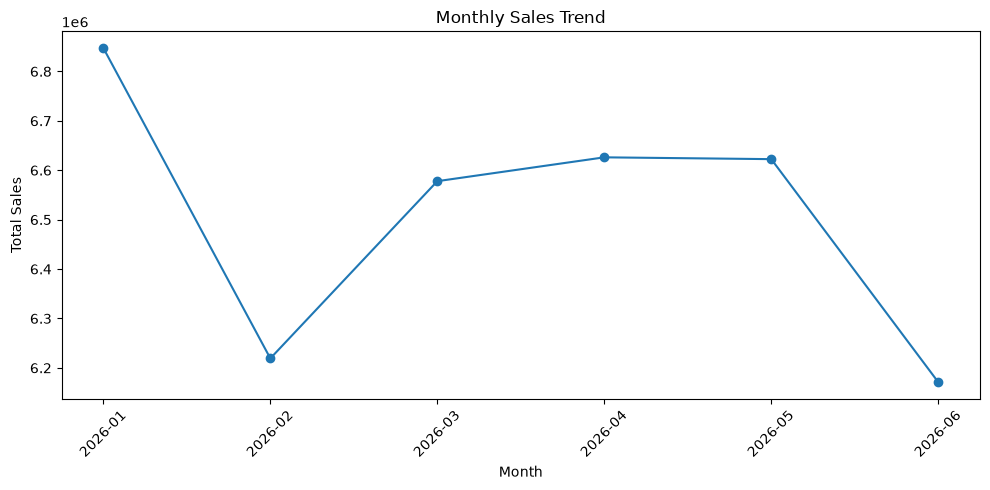

In [6]:
sales_kpis = pd.DataFrame(
    {
        "KPI": [
            "Total Sales",
            "Total Profit",
            "Total Transactions",
            "Total Quantity Sold",
            "Average Transaction Value",
            "Average Discount Percent",
        ],
        "Value": [
            round(sales["total_sales"].sum(), 2),
            round(sales["profit"].sum(), 2),
            int(len(sales)),
            int(sales["quantity_sold"].sum()),
            round(sales["total_sales"].mean(), 2),
            round(sales["discount_percent"].mean(), 2),
        ],
    }
)

display(sales_kpis)

monthly_sales = (
    sales.groupby("month", as_index=False)
    .agg(
        total_sales=("total_sales", "sum"),
        total_profit=("profit", "sum"),
        transaction_count=("sale_id", "count"),
    )
)

display(monthly_sales)

plt.figure(figsize=(10, 5))
plt.plot(
    monthly_sales["month"],
    monthly_sales["total_sales"],
    marker="o",
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Sales Performance by Product, Store, and Region

Top 10 Products by Sales


,product_id,product_name,total_sales,total_profit,quantity_sold
1,P002,Basmati Rice 5kg,5298696.00,667256.00,10526
23,P024,Earphones,4471785.00,1275375.00,10311
5,P006,Coffee 200g,3069345.50,604920.50,10953
0,P001,Atta 5kg,2793280.00,413700.00,10346
4,P005,Tea 500g,2167484.00,379859.00,10215
22,P023,USB Cable,1803231.00,554511.00,10406
11,P012,Face Wash 100ml,1785303.00,428607.00,10278
8,P009,Shampoo 180ml,1674411.75,432225.75,10527
2,P003,Sunflower Oil 1L,1580776.00,250746.00,10231
14,P015,Floor Cleaner 1L,1531747.50,388351.50,10587


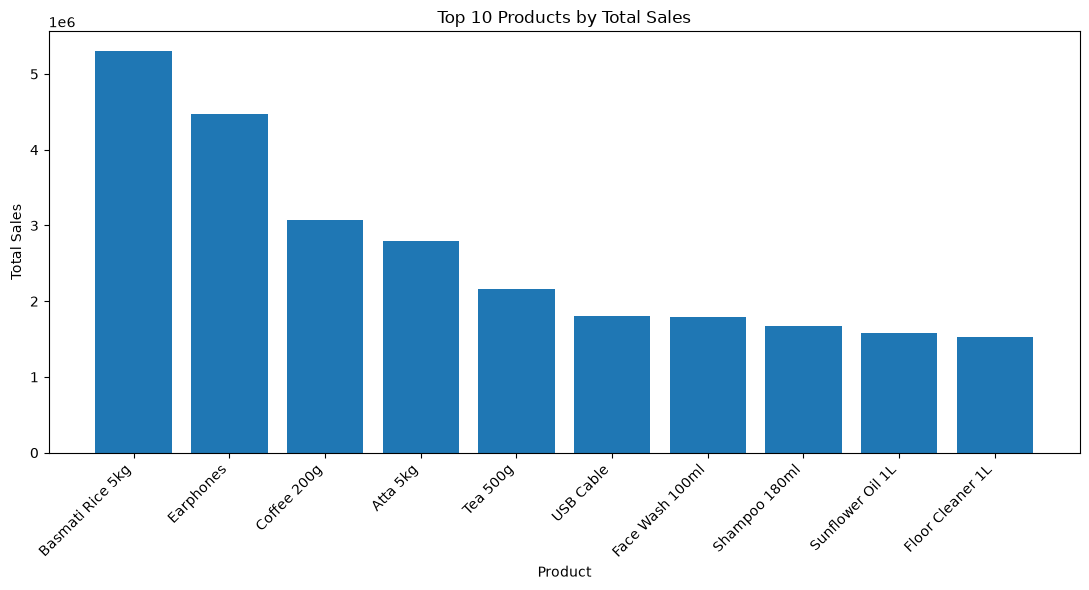

Sales by Store


,store_id,store_name,total_sales,total_profit,transaction_count
7,S008,SmartMart Kashipur,4076050.40,909088.40,4497
6,S007,SmartMart Haldwani,4051818.75,886104.75,4484
9,S010,SmartMart Mussoorie,3987174.10,881755.10,4441
5,S006,SmartMart Roorkee,3950389.70,865291.70,4385
1,S002,SmartMart Ballupur,3935042.25,880975.25,4440
0,S001,SmartMart Rajpur Road,3931878.05,869838.05,4383
8,S009,SmartMart Rudrapur,3905051.90,867198.90,4508
4,S005,SmartMart Haridwar Central,3870468.05,873376.05,4423
3,S004,SmartMart Rishikesh,3837156.70,846885.70,4338
2,S003,SmartMart Clock Tower,3518994.90,782680.90,4536


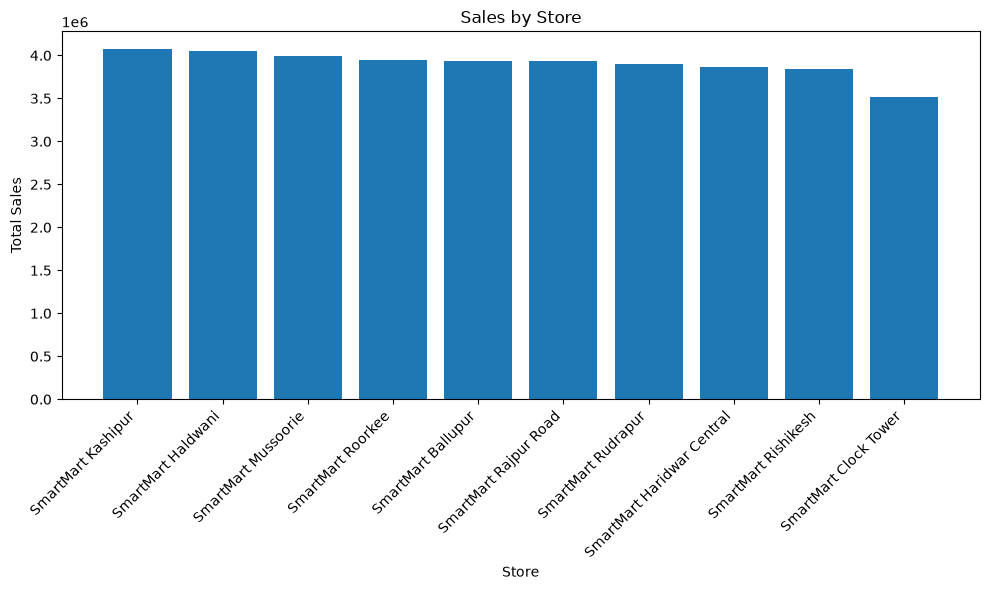

Sales by Region


,region,total_sales,total_profit,transaction_count
0,North,39064024.8,8663194.8,44435


In [7]:
sales_by_product = (
    sales.groupby(
        ["product_id", "product_name"],
        as_index=False,
    )
    .agg(
        total_sales=("total_sales", "sum"),
        total_profit=("profit", "sum"),
        quantity_sold=("quantity_sold", "sum"),
    )
    .sort_values("total_sales", ascending=False)
)

top_products = sales_by_product.head(10)

print("Top 10 Products by Sales")
display(top_products)

plt.figure(figsize=(11, 6))
plt.bar(
    top_products["product_name"],
    top_products["total_sales"],
)
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


sales_by_store = (
    sales.groupby(
        ["store_id", "store_name"],
        as_index=False,
    )
    .agg(
        total_sales=("total_sales", "sum"),
        total_profit=("profit", "sum"),
        transaction_count=("sale_id", "count"),
    )
    .sort_values("total_sales", ascending=False)
)

print("Sales by Store")
display(sales_by_store)

plt.figure(figsize=(10, 6))
plt.bar(
    sales_by_store["store_name"],
    sales_by_store["total_sales"],
)
plt.title("Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


sales_by_region = (
    sales.groupby("region", as_index=False)
    .agg(
        total_sales=("total_sales", "sum"),
        total_profit=("profit", "sum"),
        transaction_count=("sale_id", "count"),
    )
    .sort_values("total_sales", ascending=False)
)

print("Sales by Region")
display(sales_by_region)

## 7. Inventory Analysis

`is_perishable` is intentionally stored only in `products_cleaned.csv`.  
This analysis uses the cleaned inventory records and product relationships where needed.

Inventory Status Summary


,stock_status,inventory_records,total_current_stock
1,Normal,151,15490
0,Low Stock,37,919
3,Reorder Soon,34,1924
2,Overstock,28,5426


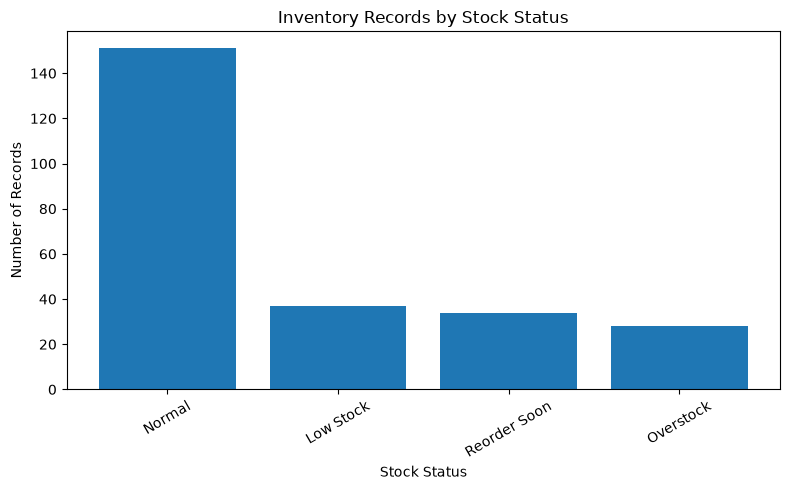

Inventory Items Requiring Attention


,inventory_id,store_id,store_name,product_id,product_name,current_stock,reorder_level,stock_status,reorder_required,days_to_expiry
248,INV00249,S010,SmartMart Mussoorie,P024,Earphones,4,25,Low Stock,Yes,NaN
66,INV00067,S003,SmartMart Clock Tower,P017,Instant Noodles Pack,5,100,Low Stock,Yes,157.0
223,INV00224,S009,SmartMart Rudrapur,P024,Earphones,7,25,Low Stock,Yes,NaN
231,INV00232,S010,SmartMart Mussoorie,P007,Packaged Juice 1L,7,50,Low Stock,Yes,155.0
73,INV00074,S003,SmartMart Clock Tower,P024,Earphones,8,25,Low Stock,Yes,NaN
...,...,...,...,...,...,...,...,...,...,...
18,INV00019,S001,SmartMart Rajpur Road,P019,Chips 150g,91,100,Reorder Soon,No,168.0
43,INV00044,S002,SmartMart Ballupur,P019,Chips 150g,93,100,Reorder Soon,No,137.0
118,INV00119,S005,SmartMart Haridwar Central,P019,Chips 150g,95,100,Reorder Soon,No,137.0
144,INV00145,S006,SmartMart Roorkee,P020,Chocolate Bar,100,120,Reorder Soon,No,154.0


In [8]:
inventory_status_summary = (
    inventory.groupby("stock_status", as_index=False)
    .agg(
        inventory_records=("inventory_id", "count"),
        total_current_stock=("current_stock", "sum"),
    )
    .sort_values("inventory_records", ascending=False)
)

print("Inventory Status Summary")
display(inventory_status_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    inventory_status_summary["stock_status"],
    inventory_status_summary["inventory_records"],
)
plt.title("Inventory Records by Stock Status")
plt.xlabel("Stock Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


inventory_attention_items = inventory[
    inventory["stock_status"].isin(
        ["Low Stock", "Reorder Soon", "Overstock"]
    )
].sort_values(
    ["stock_status", "current_stock"]
)

print("Inventory Items Requiring Attention")
display(
    inventory_attention_items[
        [
            "inventory_id",
            "store_id",
            "store_name",
            "product_id",
            "product_name",
            "current_stock",
            "reorder_level",
            "stock_status",
            "reorder_required",
            "days_to_expiry",
        ]
    ]
)

## 8. Customer Complaint Analysis

Complaints by Severity


,severity,complaint_count
1,Low,700
2,Medium,560
0,High,312


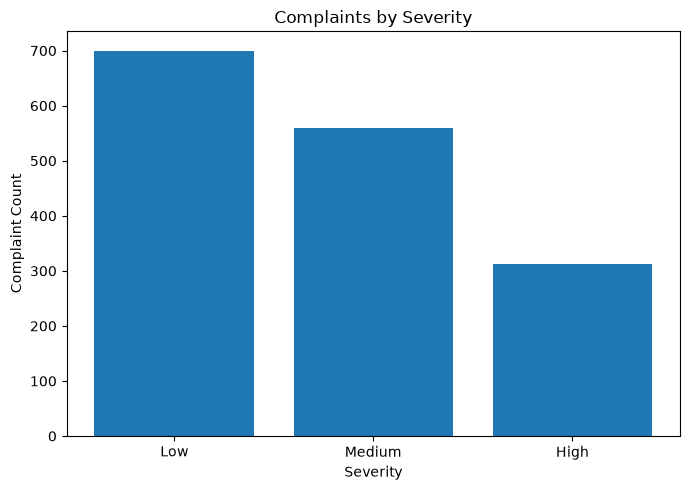

Complaints by Store


,store_id,store_name,complaint_count
2,S003,SmartMart Clock Tower,297
1,S002,SmartMart Ballupur,153
4,S005,SmartMart Haridwar Central,153
8,S009,SmartMart Rudrapur,149
9,S010,SmartMart Mussoorie,143
7,S008,SmartMart Kashipur,141
5,S006,SmartMart Roorkee,141
6,S007,SmartMart Haldwani,139
0,S001,SmartMart Rajpur Road,132
3,S004,SmartMart Rishikesh,124


Top 10 Products by Complaint Count


,product_id,product_name,complaint_count
16,P017,Instant Noodles Pack,111
18,P019,Chips 150g,105
17,P018,Biscuits 300g,104
10,P011,Soap Pack of 4,75
8,P009,Shampoo 180ml,69
7,P008,Soft Drink 750ml,67
12,P013,Dishwash Liquid 500ml,63
20,P021,Notebook,62
14,P015,Floor Cleaner 1L,62
9,P010,Toothpaste 150g,61


In [9]:
complaints_by_severity = (
    complaints.groupby("severity", as_index=False)
    .agg(
        complaint_count=("complaint_id", "count"),
    )
    .sort_values("complaint_count", ascending=False)
)

print("Complaints by Severity")
display(complaints_by_severity)

plt.figure(figsize=(7, 5))
plt.bar(
    complaints_by_severity["severity"],
    complaints_by_severity["complaint_count"],
)
plt.title("Complaints by Severity")
plt.xlabel("Severity")
plt.ylabel("Complaint Count")
plt.tight_layout()
plt.show()


complaints_by_store = (
    complaints.groupby(
        ["store_id", "store_name"],
        as_index=False,
    )
    .agg(
        complaint_count=("complaint_id", "count"),
    )
    .sort_values("complaint_count", ascending=False)
)

print("Complaints by Store")
display(complaints_by_store)


complaints_by_product = (
    complaints.groupby(
        ["product_id", "product_name"],
        as_index=False,
    )
    .agg(
        complaint_count=("complaint_id", "count"),
    )
    .sort_values("complaint_count", ascending=False)
    .head(10)
)

print("Top 10 Products by Complaint Count")
display(complaints_by_product)

## 9. Vendor Delivery Analysis

,vendor_id,vendor_name,delivery_count,average_delay_days,maximum_delay_days,average_quality_rating,total_purchase_value
8,V009,TechEase Accessories,8,4.38,15,4.00,123420.0
3,V004,CoolSip Distributors,8,4.12,15,3.62,99024.0
4,V005,GlowCare Personal Products,9,1.56,5,4.22,125086.0
1,V002,FreshDrop Oils,11,1.27,5,4.09,238680.0
0,V001,GrainPro Suppliers,9,0.89,3,4.17,261958.0
9,V010,BrightLite Electricals,8,0.88,5,4.38,77265.0
2,V003,BrewLeaf Beverages,6,0.83,3,4.33,108150.0
6,V007,QuickBite Foods,10,0.80,2,4.35,94642.0
5,V006,HomeShine Supplies,7,0.57,2,4.21,80846.0
7,V008,WriteWell Stationery,9,0.56,2,4.28,56940.0


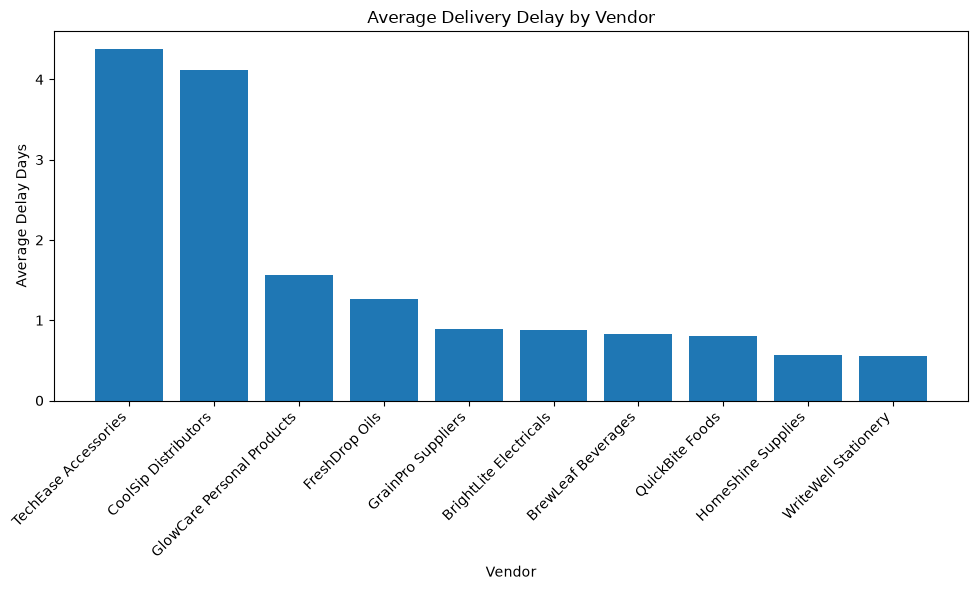

In [10]:
vendor_performance = (
    vendor_deliveries.groupby(
        ["vendor_id", "vendor_name"],
        as_index=False,
    )
    .agg(
        delivery_count=("purchase_order_id", "count"),
        average_delay_days=("delay_days", "mean"),
        maximum_delay_days=("delay_days", "max"),
        average_quality_rating=("quality_rating", "mean"),
        total_purchase_value=("purchase_value", "sum"),
    )
    .sort_values("average_delay_days", ascending=False)
)

vendor_performance["average_delay_days"] = (
    vendor_performance["average_delay_days"].round(2)
)

vendor_performance["average_quality_rating"] = (
    vendor_performance["average_quality_rating"].round(2)
)

display(vendor_performance)

plt.figure(figsize=(10, 6))
plt.bar(
    vendor_performance["vendor_name"],
    vendor_performance["average_delay_days"],
)
plt.title("Average Delivery Delay by Vendor")
plt.xlabel("Vendor")
plt.ylabel("Average Delay Days")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 10. Finance Analysis

In [11]:
finance_summary = (
    finance.groupby(
        ["store_id", "store_name"],
        as_index=False,
    )
    .agg(
        total_revenue=("total_revenue", "sum"),
        total_operating_profit=("operating_profit", "sum"),
        average_target_achievement=(
            "target_achievement_percent",
            "mean",
        ),
    )
    .sort_values("total_operating_profit", ascending=True)
)

finance_summary["average_target_achievement"] = (
    finance_summary["average_target_achievement"].round(2)
)

print("Store Finance Summary")
display(finance_summary)

high_risk_finance = finance[
    finance["risk_status"] == "High Risk"
].sort_values("operating_profit")

print("High-Risk Finance Records")
display(high_risk_finance)

Store Finance Summary


,store_id,store_name,total_revenue,total_operating_profit,average_target_achievement
3,S004,SmartMart Rishikesh,3837156.70,464812.59,106.58
2,S003,SmartMart Clock Tower,3518994.90,480748.45,65.17
5,S006,SmartMart Roorkee,3950389.70,487961.98,119.71
1,S002,SmartMart Ballupur,3935042.25,505914.99,100.90
8,S009,SmartMart Rudrapur,3905051.90,517127.65,79.37
0,S001,SmartMart Rajpur Road,3931878.05,530086.54,77.10
4,S005,SmartMart Haridwar Central,3870468.05,538153.33,80.63
7,S008,SmartMart Kashipur,4076050.40,550345.94,135.87
9,S010,SmartMart Mussoorie,3987174.10,562015.51,158.22
6,S007,SmartMart Haldwani,4051818.75,591365.46,90.04


High-Risk Finance Records


,finance_id,month,store_id,store_name,region,monthly_sales_target,total_revenue,total_cost,gross_profit,operating_expense,operating_profit,target_achievement_percent,risk_status
52,FIN00053,2026-06,S003,SmartMart Clock Tower,North,900000.0,259798.35,203569.0,56229.35,30232.72,25996.63,28.87,High Risk
50,FIN00051,2026-06,S001,SmartMart Rajpur Road,North,850000.0,589602.30,454755.0,134847.30,69676.30,65171.00,69.36,High Risk
12,FIN00013,2026-02,S003,SmartMart Clock Tower,North,900000.0,596478.05,464497.0,131981.05,65580.71,66400.34,66.28,High Risk
42,FIN00043,2026-05,S003,SmartMart Clock Tower,North,900000.0,616542.20,482561.0,133981.20,38264.65,95716.55,68.50,High Risk


In [12]:
delivery_check = vendor_deliveries.copy()

delivery_check["order_date"] = pd.to_datetime(
    delivery_check["order_date"],
    format="%Y-%m-%d",
)

delivery_check["expected_delivery_date"] = pd.to_datetime(
    delivery_check["expected_delivery_date"],
    format="%Y-%m-%d",
)

delivery_check["actual_delivery_date"] = pd.to_datetime(
    delivery_check["actual_delivery_date"],
    format="%Y-%m-%d",
)

delivery_check["ordered_quantity"] = pd.to_numeric(
    delivery_check["ordered_quantity"],
    errors="coerce",
)

delivery_check["received_quantity"] = pd.to_numeric(
    delivery_check["received_quantity"],
    errors="coerce",
)

delivery_check["delay_days"] = pd.to_numeric(
    delivery_check["delay_days"],
    errors="coerce",
)

expected_before_order = (
    delivery_check["expected_delivery_date"]
    < delivery_check["order_date"]
).sum()

actual_before_order = (
    delivery_check["actual_delivery_date"]
    < delivery_check["order_date"]
).sum()

actual_before_expected = (
    delivery_check["actual_delivery_date"]
    < delivery_check["expected_delivery_date"]
).sum()

received_more_than_ordered = (
    delivery_check["received_quantity"]
    > delivery_check["ordered_quantity"]
).sum()

calculated_delay = (
    delivery_check["actual_delivery_date"]
    - delivery_check["expected_delivery_date"]
).dt.days

delay_mismatch = (
    calculated_delay != delivery_check["delay_days"]
).sum()

print("Expected delivery before order date:", expected_before_order)
print("Actual delivery before order date:", actual_before_order)
print("Actual delivery before expected date:", actual_before_expected)
print("Received quantity greater than ordered:", received_more_than_ordered)
print("Delay-days mismatch:", delay_mismatch)

Expected delivery before order date: 0
Actual delivery before order date: 0
Actual delivery before expected date: 0
Received quantity greater than ordered: 0
Delay-days mismatch: 0
